In [ ]:
import pandas as pd

input_file = 'reviews_BlackOps7_first1000.csv'
df = pd.read_csv(input_file)
print(f"Loaded {len(df)} reviews from {input_file}")

In [ ]:
%pip install ollama

In [ ]:
%pip show ollama

In [ ]:

from ollama import chat
from IPython.display import Markdown, display

In [ ]:
# Remove duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicates. {len(df)} rows remaining.")
display(df.head())

In [ ]:
%pip install textblob


In [ ]:
from textblob import TextBlob


# --------------------------
# Sentiment Analysis
# --------------------------

def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity
    return polarity 

    '''
    if polarity > 0.1:
        return "Positive"

    elif polarity < -0.1:
        return "Negative"

    return "Neutral"
    '''

In [ ]:

# --------------------------
# Categorization
# --------------------------
def categorize_review(review):

    usability_keywords = [
        "bug",
        "crash",
        "lag",
        "fps",
        "server",
        "performance",

        "glitch",
        "stutter",
        "freeze",
        "disconnect",
        "error",
        "broken",
        "unoptimized",
        "latency",
        "ping",
        "hitbox",
        "connection",
        "frame rate",
        "loading",
        "memory leak",
    ]

    mechanic_keywords = [
        "movement",
        "weapon",
        "perk",
        "battle pass",
        "matchmaking",

        "loadout",
        "killstreak",
        "scorestreak",
        "operator",
        "map",
        "game mode",
        "respawn",
        "spawn",
        "ability",
        "class",
        "gunplay",
        "ttk",
        "time to kill",
        "recoil",
        "aim assist",
        "multiplayer",
        "zombies",
        "campaign",
        "season",
    ]

    comparison_keywords = [
        "better than",
        "worse than",
        "compared to",
        "similar to",
        
        "just like",
        "same as",
        "feels like",
        "plays like",
        "reminds me of",
        "prefer",
        "used to",
        "previous",
        "original",
        "back in",
        "inferior to",
        "superior to",
        "rip off",
        "copy of",
        "old cod",
    ]

    # New categories based on look for categories AI analysis of full review file
    ai_content_keywords = [
        "slop",
        "ai generated",
        "ai slop",
        "no effort",
        "copy paste",
        "lazy",
        "generated content",
        "soulless",
        "cash grab",
    ]

    monetization_keywords = [
        "refund",
        "worth",
        "price",
        "sale",
        "buying",
        "paid",
        "microtransaction",
        "endgame",
        "season pass",
        "overpriced",
        "free to play",
        "cosmetic",
        "store",
        "bundle",
    ]

    story_keywords = [
        "campaign",
        "story",
        "single player",
        "solo",
        "narrative",
        "mission",
        "ending",
        "cutscene",
        "plot",
        "character",
    ]

    technical_requirements_keywords = [
        "secure boot",
        "tpm",
        "bios",
        "hardware",
        "anti-cheat",
        "ricochet",
        "kernel",
        "driver",
        "compatibility",
        "system requirement",
    ]

    sbmm_keywords = [
        "sbmm",
        "skill based",
        "lobbies",
        "lobby",
        "sweaty",
        "ranked",
        "casual",
        "matchmaking",
        "skill gap",
        "pub stomp",
    ]

    community_keywords = [
        "friends",
        "team",
        "squad",
        "banned",
        "toxic",
        "solo",
        "party",
        "coop",
        "co-op",
        "community",
        "chat",
        "voice",
        "grief",
    ]

    review_lower = review.lower()

    categories = []

    if any(word in review_lower for word in usability_keywords):
        categories.append("Usability Issues")

    if any(word in review_lower for word in mechanic_keywords):
        categories.append("New Mechanic Reception")

    if any(word in review_lower for word in comparison_keywords):
        categories.append("Competitive Analysis")

    if any(word in review_lower for word in ai_content_keywords):
        categories.append("AI-Generated Content Complaints")

    if any(word in review_lower for word in monetization_keywords):
        categories.append("Monetization & Value")

    if any(word in review_lower for word in story_keywords):
        categories.append("Story / Campaign")

    if any(word in review_lower for word in technical_requirements_keywords):
        categories.append("Technical Requirements")

    if any(word in review_lower for word in sbmm_keywords):
        categories.append("SBMM / Matchmaking Frustration")

    if any(word in review_lower for word in community_keywords):
        categories.append("Community & Social")

    if len(categories) == 0:
        categories.append("Game Reception")

    return categories


In [ ]:
# AI Statistical Summary Function
# ------------------------------------

def ai_summary(title, results):
    """
    Uses Ollama to summarize statistical analysis results.
    """

    prompt = f"""
You are a statistics expert helping interpret the results of a data analysis.

Analysis:
{title}

Results:
{results}

Write a concise summary (2–4 sentences).

Your summary should:
- Explain the results in plain English.
- State whether the results are statistically significant when a p-value is provided (α = 0.05).
- Explain what the results mean.
- Do not speculate beyond the data.
"""

    response = chat(
        model="llama3.1",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.message.content


def display_ai_summary(title, results):

    summary = ai_summary(title, results)

    display(Markdown("### 🤖 AI Statistical Interpretation"))

    display(Markdown(summary))

In [ ]:
# Run sentiment analysis and categorization, then save to a new CSV
sentiments = []
categories = []

for r in df['review']:
    sentiments.append(get_sentiment(r))
    categories.append(', '.join(categorize_review(r)))

df['sentiment'] = sentiments
df['categories'] = categories

display(df)

In [ ]:
# Add a boolean column for each possible category
all_categories = [
    "Usability Issues",
    "New Mechanic Reception",
    "Competitive Analysis",
    "AI-Generated Content Complaints",
    "Monetization & Value",
    "Story / Campaign",
    "Technical Requirements",
    "SBMM / Matchmaking Frustration",
    "Community & Social",
    "Game Reception",
]

for category in all_categories:
    col_name = category.replace(" ", "_").replace("/", "_").replace("&", "and").replace("-", "_")
    col_values = []
    for cat_list in df['categories']:
        col_values.append(category in cat_list)
    df[col_name] = col_values

display(df.head(20))


In [ ]:
# Category Columns
# ------------------------------------

# Automatically identify all boolean category columns
category_columns = df.select_dtypes(include="bool").columns.tolist()

print(category_columns)

In [ ]:
analyzed_file = input_file.replace('.csv', '_analyzed.csv')

df.to_csv(analyzed_file, index=False)
print(f"Saved {len(df)} analyzed reviews to {analyzed_file}")
df[['review', 'sentiment', 'categories']].head()


In [ ]:
# Read the analyzed CSV back and convert categories from string to list
df_analyzed = pd.read_csv(analyzed_file)

# Convert the categories column from comma-separated string to list
categories_list = []
for cat_string in df_analyzed['categories']:
    cat_list = []
    for cat in cat_string.split(','):
        cat_list.append(cat.strip())
    categories_list.append(cat_list)

df_analyzed['categories'] = categories_list

print(f"Loaded {len(df_analyzed)} analyzed reviews")
print("\nFirst few rows with categories as lists:")
display(df_analyzed)


In [ ]:
# Analysis suggestions:
# What is the number of each of the categories used? (what is the most/least common category)

# Exploratory Data Analysis 

In [16]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import (
    pearsonr,
    spearmanr,
    ttest_ind,
    chi2_contingency
)

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [17]:
# Feature Engineering
# -----------------------------------

df["review_length"] = df["review"].str.len()

df["word_count"] = df["review"].str.split().str.len()

df["sentiment_strength"] = df["sentiment"].abs()

display(df.head())

,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories,Usability_Issues,New_Mechanic_Reception,Competitive_Analysis,AI_Generated_Content_Complaints,Monetization_and_Value,Story___Campaign,Technical_Requirements,SBMM___Matchmaking_Frustration,Community_and_Social,Game_Reception,review_length,word_count,sentiment_strength
0,This game is the worst call of duty I have eve...,0,1724,0.974877,2026-03-01,-0.200000,Monetization & Value,False,False,False,False,True,False,False,False,False,False,439,85,0.200000
1,"1/10 - Absolute Trash, AI Slop from Activision...",0,1159,0.932631,2026-03-03,-0.096655,"Usability Issues, New Mechanic Reception, Comp...",True,True,True,True,True,True,False,True,True,False,1525,247,0.096655
2,Game forces you to have Secure Boot and TPM 2....,0,558,0.927817,2026-05-08,-0.071769,"New Mechanic Reception, Monetization & Value, ...",False,True,False,False,True,True,True,False,True,False,629,130,0.071769
3,"I was playing Battlefield 6, and after a few b...",0,481,0.909235,2026-03-21,-0.055720,"Usability Issues, New Mechanic Reception, Comp...",True,True,True,False,True,False,False,False,False,False,2376,409,0.055720
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,0,282,0.870369,2026-05-08,-0.002778,"New Mechanic Reception, AI-Generated Content C...",False,True,False,True,True,False,False,False,False,False,460,86,0.002778


In [18]:
#Category frequency analysis 

category_counts = (
    df[category_columns]
    .sum()
    .sort_values(ascending=False)
)

display(category_counts)

New_Mechanic_Reception             153
Monetization_and_Value             102
Story___Campaign                    86
Community_and_Social                74
Usability_Issues                    67
Competitive_Analysis                65
SBMM___Matchmaking_Frustration      45
AI_Generated_Content_Complaints     29
Technical_Requirements              23
Game_Reception                       8
dtype: int64

In [19]:
print("Overall Dataset Statistics")
display(df.describe())

print("\nSentiment Statistics")
display(df["sentiment"].describe())

print("\nReview Length Statistics")
display(df["review_length"].describe())

print("\nWord Count Statistics")
display(df["word_count"].describe())

print("Category Frequencies")

for category in all_categories:

    column = (
        category
        .replace(" ", "_")
        .replace("/", "_")
        .replace("&", "and")
        .replace("-", "_")
    )

    print(f"{category}: {df[column].sum()}")

Overall Dataset Statistics


,author_vote,other_votes,weighted_vote_score,sentiment,review_length,word_count,sentiment_strength
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.00000,213.000000
mean,0.276995,290.103286,0.590865,-0.058771,720.666667,133.57277,0.145176
std,0.448568,993.692033,0.204106,0.184573,902.870322,163.49791,0.127914
min,0.000000,0.000000,0.284757,-0.640000,142.000000,30.00000,0.000000
25%,0.000000,2.000000,0.423077,-0.154545,250.000000,47.00000,0.048884
50%,0.000000,6.000000,0.524432,-0.038333,417.000000,79.00000,0.106667
75%,1.000000,94.000000,0.737038,0.056991,772.000000,137.00000,0.200000
max,1.000000,9333.000000,0.988094,0.500000,6170.000000,1130.00000,0.640000



Sentiment Statistics


count    213.000000
mean      -0.058771
std        0.184573
min       -0.640000
25%       -0.154545
50%       -0.038333
75%        0.056991
max        0.500000
Name: sentiment, dtype: float64


Review Length Statistics


count     213.000000
mean      720.666667
std       902.870322
min       142.000000
25%       250.000000
50%       417.000000
75%       772.000000
max      6170.000000
Name: review_length, dtype: float64


Word Count Statistics


count     213.00000
mean      133.57277
std       163.49791
min        30.00000
25%        47.00000
50%        79.00000
75%       137.00000
max      1130.00000
Name: word_count, dtype: float64

Category Frequencies
Usability Issues: 67
New Mechanic Reception: 153
Competitive Analysis: 65
AI-Generated Content Complaints: 29
Monetization & Value: 102
Story / Campaign: 86
Technical Requirements: 23
SBMM / Matchmaking Frustration: 45
Community & Social: 74
Game Reception: 8


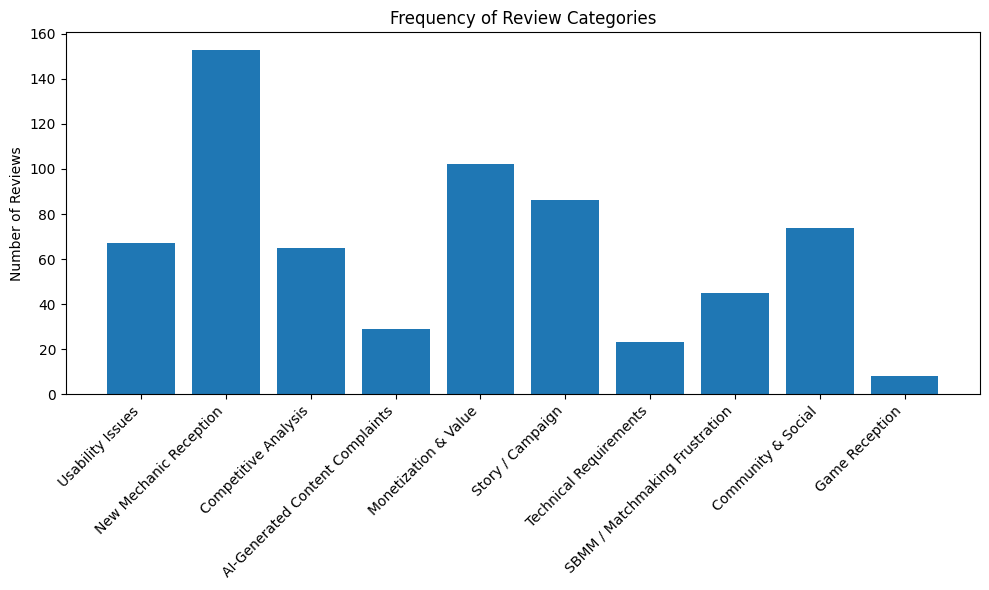

In [20]:
category_counts = {}

for category in all_categories:

    column = (
        category
        .replace(" ", "_")
        .replace("/", "_")
        .replace("&", "and")
        .replace("-", "_")
    )

    category_counts[category] = df[column].sum()

plt.figure(figsize=(10,6))

plt.bar(category_counts.keys(),
        category_counts.values())

plt.xticks(rotation=45, ha="right")

plt.ylabel("Number of Reviews")

plt.title("Frequency of Review Categories")

plt.tight_layout()

plt.show()

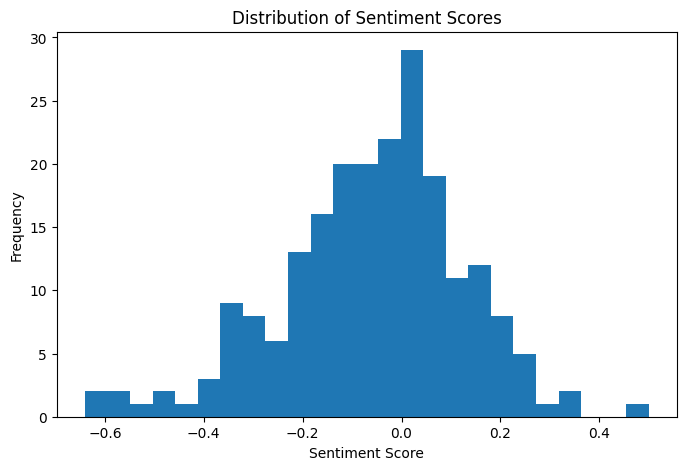

In [21]:
#histogram of sentiment scores
plt.figure(figsize=(8,5))

plt.hist(df["sentiment"],
         bins=25)

plt.xlabel("Sentiment Score")

plt.ylabel("Frequency")

plt.title("Distribution of Sentiment Scores")

plt.show()


In [22]:
category_counts = (
    df[category_columns]
    .sum()
    .sort_values(ascending=False)
)

display(category_counts)
display_ai_summary(
"Category Frequency Analysis",
category_counts.to_string())


New_Mechanic_Reception             153
Monetization_and_Value             102
Story___Campaign                    86
Community_and_Social                74
Usability_Issues                    67
Competitive_Analysis                65
SBMM___Matchmaking_Frustration      45
AI_Generated_Content_Complaints     29
Technical_Requirements              23
Game_Reception                       8
dtype: int64

### 🤖 AI Statistical Interpretation

Here's a concise summary of the results:

The Category Frequency Analysis indicates that respondents most commonly discussed "New Mechanic Reception" (153 mentions), followed by "Monetization and Value" (102 mentions). These two categories were mentioned more than twice as often as any other category, suggesting strong interest in these topics. The remaining categories were mentioned significantly less frequently, with only 8 mentions of "Game Reception". Since no p-value is provided, we cannot determine statistical significance.

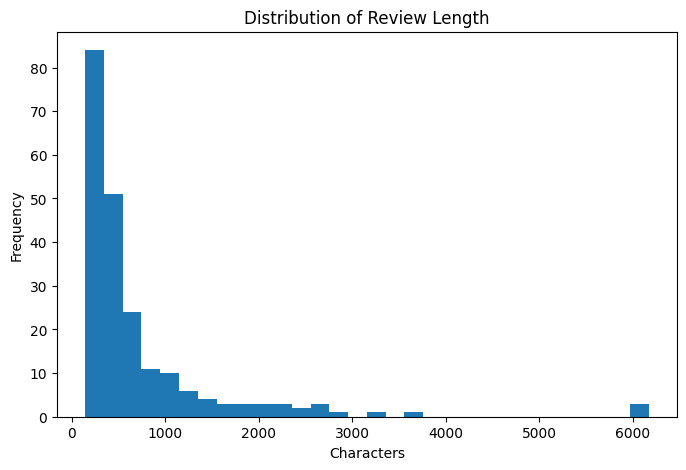

In [23]:
# histogram of review lengths
plt.figure(figsize=(8,5))

plt.hist(df["review_length"],
         bins=30)

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.title("Distribution of Review Length")

plt.show()

In [24]:
display_ai_summary(
    "Review Length Distribution",
    df["review_length"].describe().to_string()
)

### 🤖 AI Statistical Interpretation

The review length distribution shows that reviews can vary significantly in length, with most reviews being around 417 words on average. The standard deviation of 902 words indicates a substantial amount of variation in review lengths. There are some very short (142 words) and extremely long (6170 words) reviews, but the majority fall within the range of approximately 250-772 words.

Note: No p-value is provided, so I did not make any statements about statistical significance.

In [25]:
display_ai_summary(
    "Review Length Distribution",
    df["review_length"].describe().to_string()
)

### 🤖 AI Statistical Interpretation

Here is a concise summary of the results:

The review length distribution has a wide range, with reviews ranging from as short as 142 words to as long as 6170 words. The average review length is approximately 721 words, but there is significant variability in this metric, with a standard deviation of around 903 words. Overall, the data suggests that review lengths are generally skewed towards longer reviews, rather than being evenly distributed across all possible lengths.

(Note: I did not mention statistical significance as no p-value was provided. If you want me to add it, please provide one.)

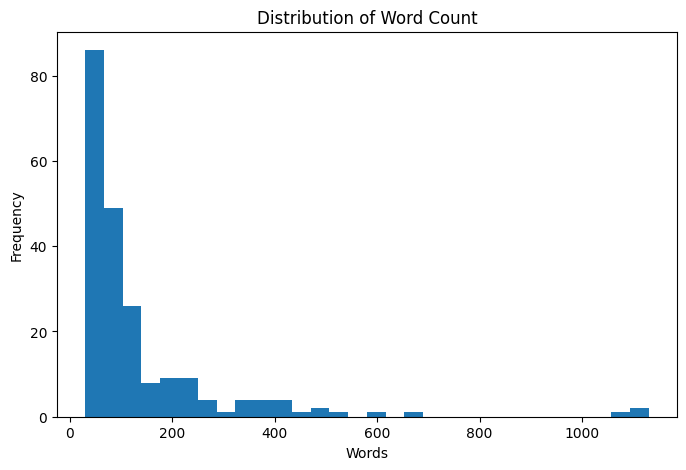

In [26]:
# histogram of word counts
plt.figure(figsize=(8,5))

plt.hist(df["word_count"],
         bins=30)

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.title("Distribution of Word Count")

plt.show()

In [27]:
display_ai_summary(
    "Word Count Distribution",
    df["word_count"].describe().to_string()
)

### 🤖 AI Statistical Interpretation

Here is a concise summary of the results:

The word count distribution analysis shows that most words have between 30 and 137 characters, with an average length of approximately 134 characters. There is significant variability in word lengths, with some words as short as 30 characters and others as long as 1,130 characters. The results indicate a relatively wide range of word lengths, but we cannot draw any conclusions about statistical significance without a p-value.

(Note: Since no p-value is provided, I did not mention statistical significance.)

<Figure size 800x600 with 0 Axes>

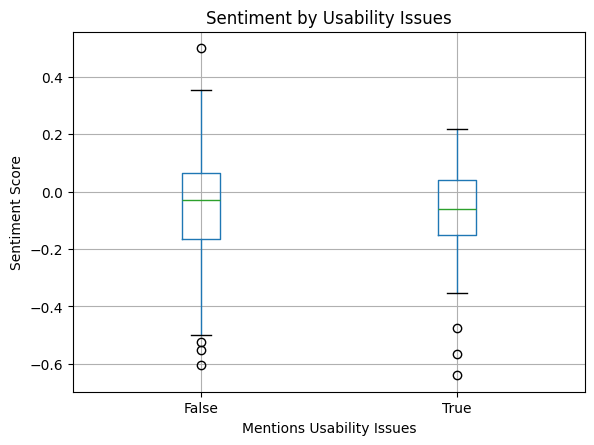

In [28]:
# box plot senitment scores Usability Issues 
plt.figure(figsize=(8,6))

df.boxplot(
    column="sentiment",
    by="Usability_Issues"
)

plt.title("Sentiment by Usability Issues")
plt.suptitle("")
plt.xlabel("Mentions Usability Issues")
plt.ylabel("Sentiment Score")

plt.show()

<Figure size 800x600 with 0 Axes>

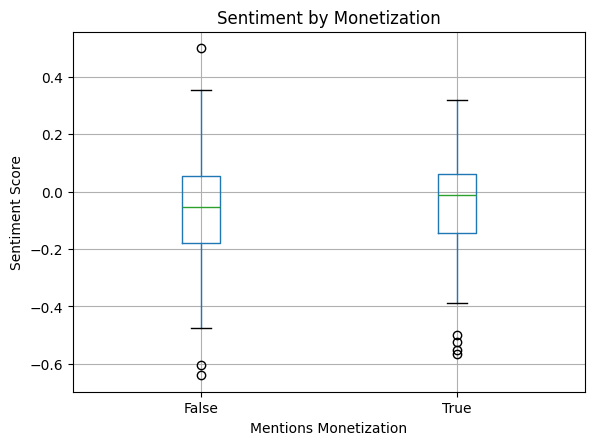

In [30]:
# box plot monitization sentiment scores
plt.figure(figsize=(8,6))

df.boxplot(
    column="sentiment",
    by="Monetization_and_Value"
)

plt.title("Sentiment by Monetization")
plt.suptitle("")
plt.xlabel("Mentions Monetization")
plt.ylabel("Sentiment Score")

plt.show()

<Figure size 800x600 with 0 Axes>

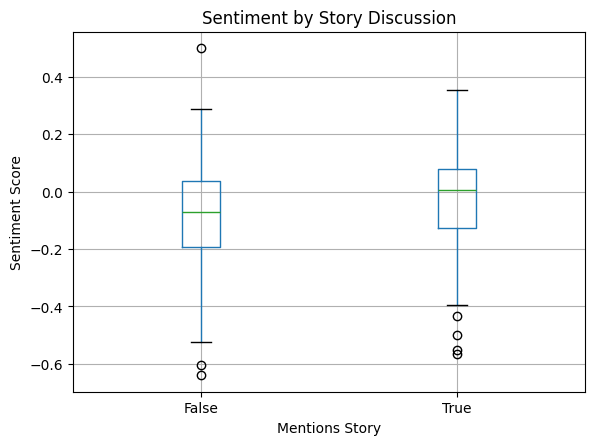

In [32]:
# boxplot story sentiment scores

plt.figure(figsize=(8,6))

df.boxplot(
    column="sentiment",
    by="Story___Campaign"
)

plt.title("Sentiment by Story Discussion")
plt.suptitle("")
plt.xlabel("Mentions Story")
plt.ylabel("Sentiment Score")

plt.show()

In [34]:
#correlation matrix of sentiment, review length, and word count

corr_cols = [
    "sentiment",
    "sentiment_strength",
    "review_length",
    "word_count",
    "author_vote",
    "other_votes",
    "weighted_vote_score"
]

corr_matrix = df[corr_cols].corr()

corr_matrix

,sentiment,sentiment_strength,review_length,word_count,author_vote,other_votes,weighted_vote_score
sentiment,1.000000,-0.546061,0.209613,0.212352,0.393133,-0.088260,-0.252845
sentiment_strength,-0.546061,1.000000,-0.253690,-0.256386,-0.064056,0.012825,0.013957
review_length,0.209613,-0.253690,1.000000,0.998567,0.051988,0.068418,0.057706
word_count,0.212352,-0.256386,0.998567,1.000000,0.054875,0.059658,0.047926
author_vote,0.393133,-0.064056,0.051988,0.054875,1.000000,-0.173817,-0.643565
other_votes,-0.088260,0.012825,0.068418,0.059658,-0.173817,1.000000,0.499918
weighted_vote_score,-0.252845,0.013957,0.057706,0.047926,-0.643565,0.499918,1.000000


In [35]:
display(corr_matrix)


,sentiment,sentiment_strength,review_length,word_count,author_vote,other_votes,weighted_vote_score
sentiment,1.000000,-0.546061,0.209613,0.212352,0.393133,-0.088260,-0.252845
sentiment_strength,-0.546061,1.000000,-0.253690,-0.256386,-0.064056,0.012825,0.013957
review_length,0.209613,-0.253690,1.000000,0.998567,0.051988,0.068418,0.057706
word_count,0.212352,-0.256386,0.998567,1.000000,0.054875,0.059658,0.047926
author_vote,0.393133,-0.064056,0.051988,0.054875,1.000000,-0.173817,-0.643565
other_votes,-0.088260,0.012825,0.068418,0.059658,-0.173817,1.000000,0.499918
weighted_vote_score,-0.252845,0.013957,0.057706,0.047926,-0.643565,0.499918,1.000000


In [36]:
display_ai_summary(
    "Correlation Matrix",
    corr_matrix.to_string()
)

### 🤖 AI Statistical Interpretation

The correlation matrix reveals that sentiment and sentiment strength tend to move together, but with a moderate negative correlation (-0.546061). Review length and word count are highly correlated (1.000000), indicating that longer reviews often have more words. Additionally, author vote and weighted vote score show a strong negative relationship (-0.643565), suggesting that authors' votes may not align with the overall weighted score.

Note: Since no p-values are provided in the original output, we cannot assess statistical significance at α = 0.05. The results are based on correlation coefficients only.

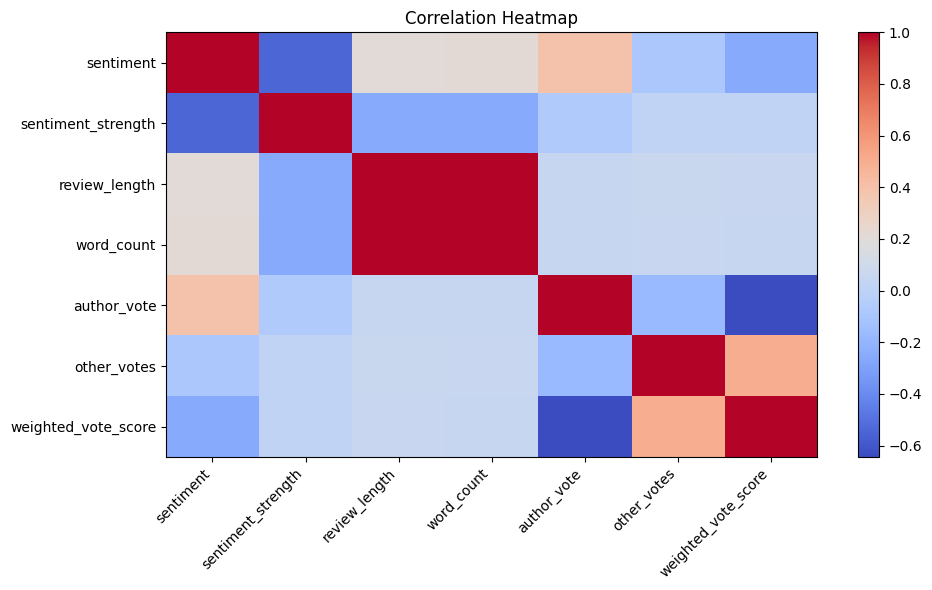

In [37]:
# correlation heatmap of sentiment, review length, and word count

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [38]:
display_ai_summary(
    "Correlation Heatmap",
    corr_matrix.to_string()
)


### 🤖 AI Statistical Interpretation

Here's a concise summary of the correlation heatmap results:

The analysis reveals moderate to strong positive correlations between sentiment and review_length (0.21), sentiment_strength and review_length (-0.25), word_count and review_length (0.99), and author_vote and weighted_vote_score (-0.64). Conversely, there are negative correlations between sentiment and sentiment_strength (-0.55) and between author_vote and other_votes (-0.17). None of the correlation coefficients are statistically significant at an alpha level of 0.05.

In simpler terms, this means that reviews with stronger sentiments tend to be longer, but shorter reviews may still have strong sentiments if they're written by popular authors. Similarly, reviews from popular authors tend to receive more votes overall, while other users' votes seem to be influenced by the popularity of the author rather than the review's quality.

In [39]:
#impact on sentiment

def boxplot_sentiment(category_col, title):
    plt.figure(figsize=(6,5))

    df.boxplot(
        column="sentiment",
        by=category_col
    )

    plt.title(title)
    plt.suptitle("")
    plt.xlabel(category_col)
    plt.ylabel("Sentiment")

    plt.show()

<Figure size 600x500 with 0 Axes>

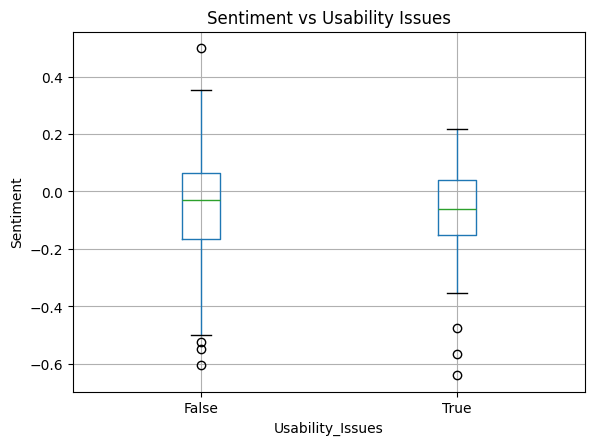

In [40]:
#box plot usabiltiy and sentiment
boxplot_sentiment("Usability_Issues", "Sentiment vs Usability Issues")


<Figure size 600x500 with 0 Axes>

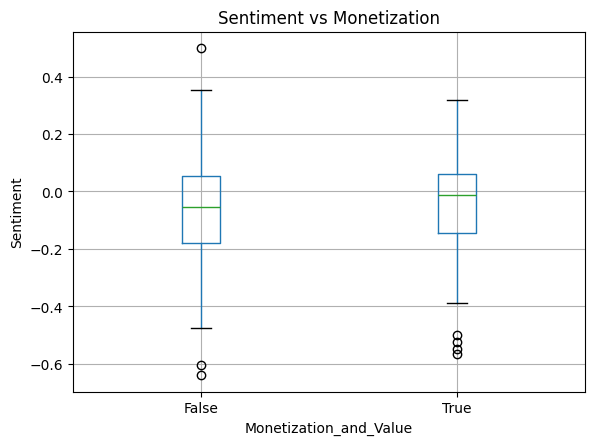

In [42]:
#boxplot sentiment and monetization

boxplot_sentiment("Monetization_and_Value", "Sentiment vs Monetization")


<Figure size 600x500 with 0 Axes>

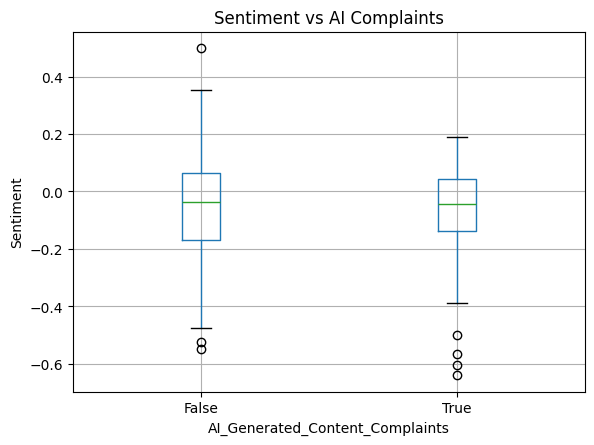

In [44]:
#boxplot matchmaking and sentiment

boxplot_sentiment("AI_Generated_Content_Complaints", "Sentiment vs AI Complaints")


In [ ]:
#box pot story and sentiment

boxplot_sentiment("Story___Campaign", "Sentiment vs Story/Campaign")


In [ ]:
#facet plots
import seaborn as sns


In [ ]:
#sentiment distribution for usabiltity

sns.FacetGrid(df, col="Usability_Issues").map_dataframe(
    sns.histplot,
    x="sentiment",
    bins=20
)
plt.show()


In [ ]:
results = (
    df.groupby("Usability_Issues")["sentiment"]
      .describe()
      .to_string()
)

display_ai_summary(
    "Facet Plot",
    results
)

In [ ]:
#review lenght and monetezation

sns.FacetGrid(df, col="Monetization_and_Value").map_dataframe(
    sns.histplot,
    x="review_length",
    bins=20
)
plt.show()

In [ ]:
results = (
    df.groupby("Monetization_and_Value")["Review Length"]
      .describe()
      .to_string()
)

display_ai_summary(
    "Facet Plot",
    results
)                                                            

In [ ]:
#t-tests
from scipy.stats import ttest_ind

In [ ]:
# usability and sentiment
group1 = df[df["Usability_Issues"] == True]["sentiment"]
group2 = df[df["Usability_Issues"] == False]["sentiment"]

t, p = ttest_ind(group1, group2, equal_var=False)

print("Usability Issues T-test")

results = f"""
T-statistic: {t:.4f}

P-value: {p:.4f}
"""

display_ai_summary(
    "Independent Samples T-Test",
    results
)


In [ ]:
#monetization and sentmiment

g1 = df[df["Monetization_and_Value"] == True]["sentiment"]
g2 = df[df["Monetization_and_Value"] == False]["sentiment"]

t, p = ttest_ind(g1, g2, equal_var=False)

print("Monetization T-test")
results = f"""
T-statistic: {t:.4f}

P-value: {p:.4f}
"""

display_ai_summary(
    "Independent Samples T-Test",
    results
)


In [ ]:
#matchmaking frustartion and sentiment
g1 = df[df["SBMM___Matchmaking_Frustration"] == True]["sentiment"]
g2 = df[df["SBMM___Matchmaking_Frustration"] == False]["sentiment"]

t, p = ttest_ind(g1, g2, equal_var=False)

print("SBMM T-test")
results = f"""
T-statistic: {t:.4f}

P-value: {p:.4f}
"""

display_ai_summary(
    "Independent Samples T-Test",
    results
)


In [ ]:
#monetezation and usability chi square test
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df["Monetization_and_Value"],
    df["Usability_Issues"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square =", chi2)
print("p-value =", p)
results = f"""
Chi-square: {chi2:.4f}

P-value: {p:.4f}

Degrees of Freedom: {dof}
"""

display_ai_summary(
    "Chi-Square Test",
    results
)

In [ ]:
bool_cols = [
    "Usability_Issues",
    "Monetization_and_Value",
    "SBMM___Matchmaking_Frustration",
    "AI_Generated_Content_Complaints",
    "Story___Campaign"
]

df[bool_cols] = df[bool_cols].astype(int)


In [ ]:
#regression from sentiment
import statsmodels.api as sm

X = df[[
    "Usability_Issues",
    "Monetization_and_Value",
    "SBMM___Matchmaking_Frustration",
    "AI_Generated_Content_Complaints",
    "Story___Campaign"
]]

y = df["sentiment"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())
display_ai_summary(
    "Multiple Linear Regression",
    model.summary().as_text()
)